In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [81]:
df_raw = pd.read_csv("../data/heart.csv")
df = df_raw.copy()
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [82]:
df.shape

(1025, 14)

In [83]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Columns: 14 entries, age to target
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [84]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [85]:
df.isnull().sum().sum()

np.int64(0)

In [86]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [87]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach']
categorical_cols = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca',
    'thal',
]
one_hot_columns = ["cp", "restecg", "slope", "thal", "ca"]

In [88]:
df[continuous_cols].describe()

,age,trestbps,chol,thalach
count,302.00000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536
std,9.04797,17.563394,51.753489,22.903527
min,29.00000,94.000000,126.000000,71.000000
25%,48.00000,120.000000,211.000000,133.250000
50%,55.50000,130.000000,240.500000,152.500000
75%,61.00000,140.000000,274.750000,166.000000
max,77.00000,200.000000,564.000000,202.000000


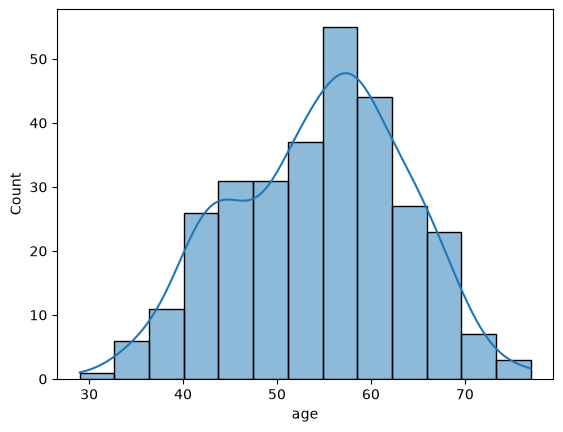

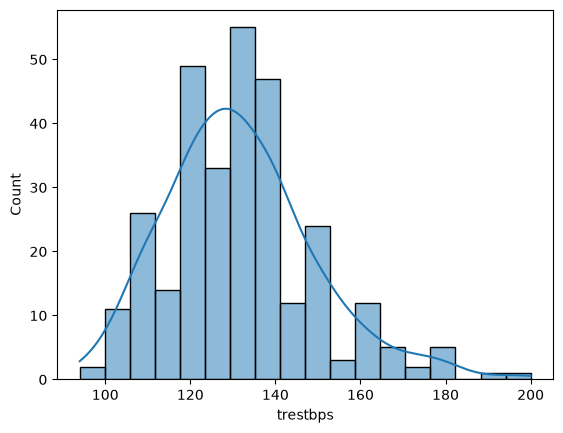

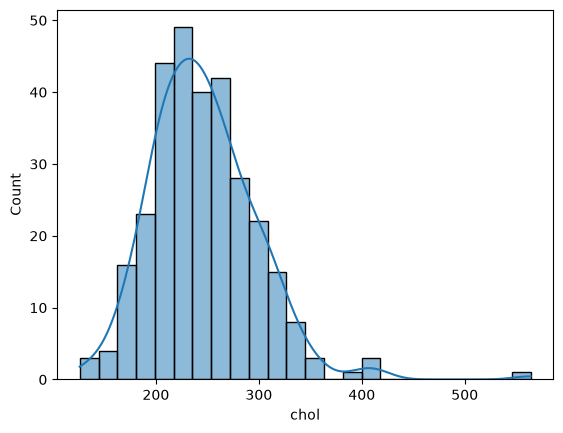

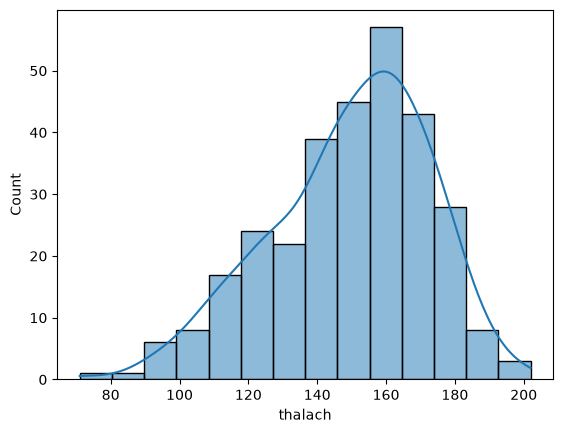

In [89]:
for col in continuous_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

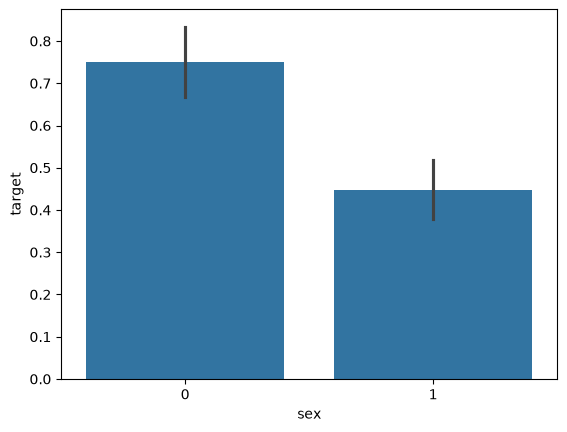

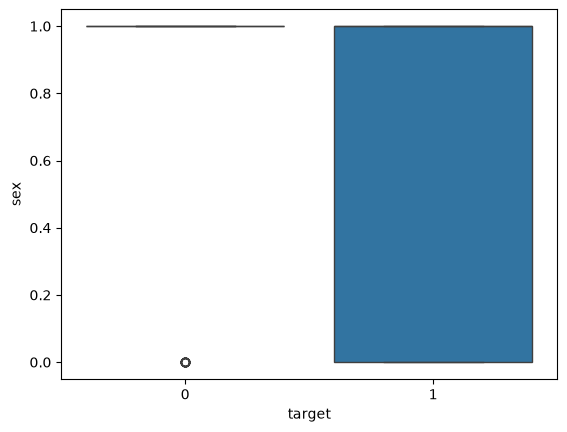

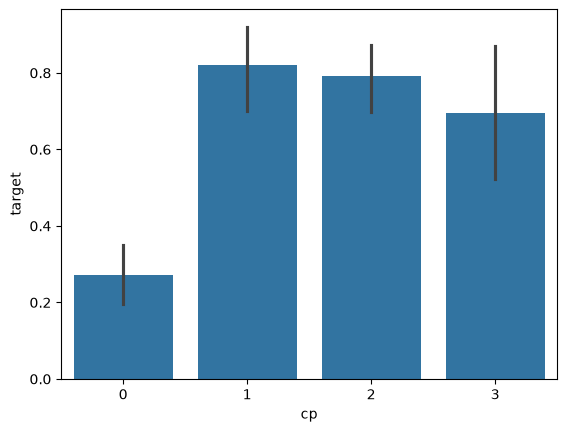

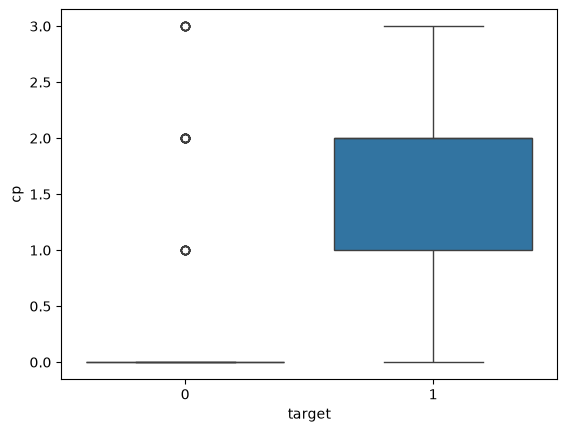

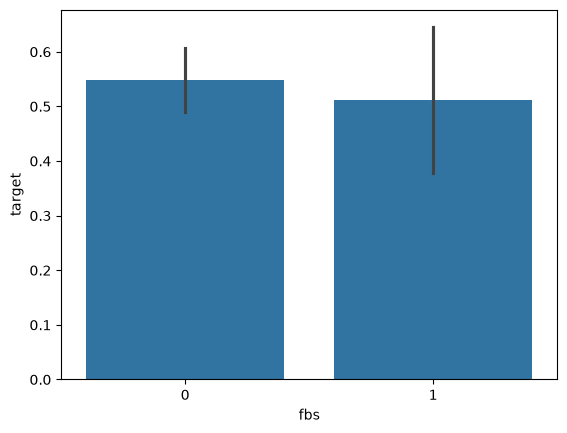

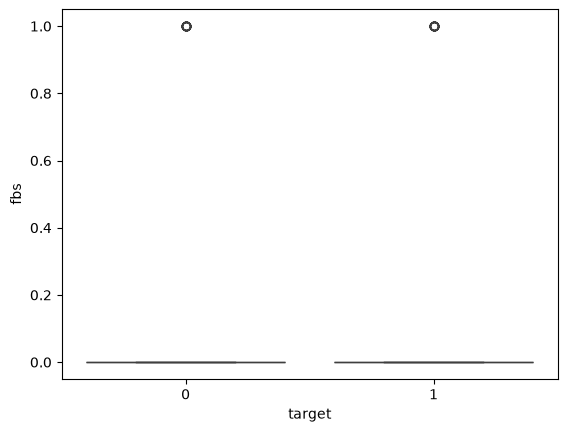

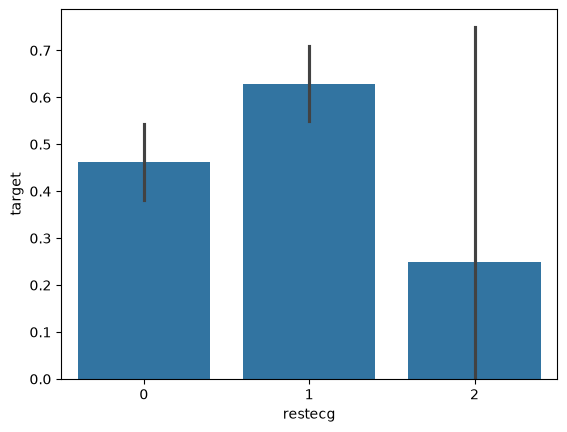

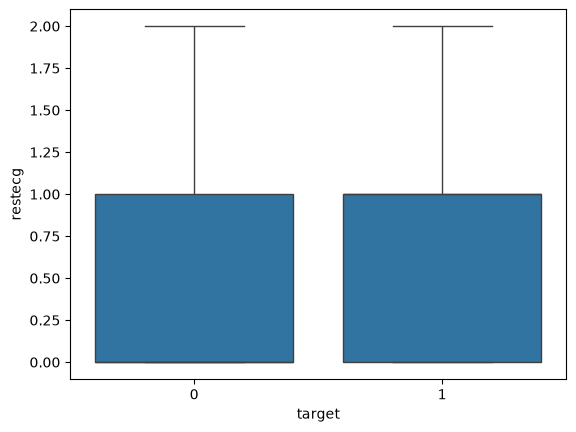

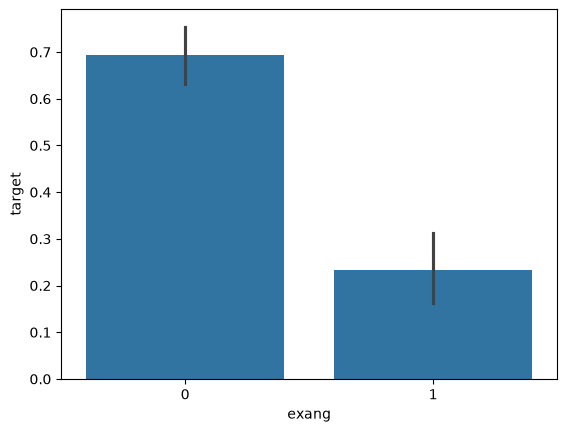

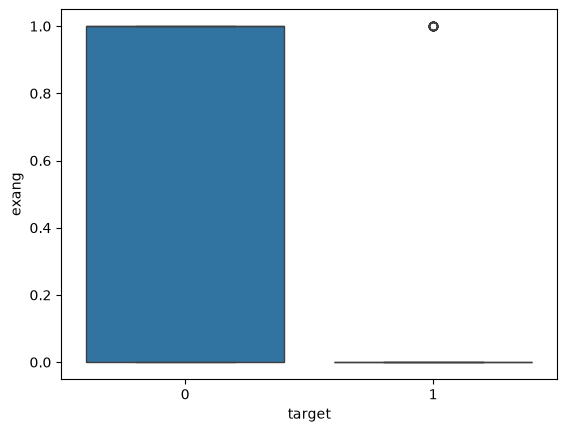

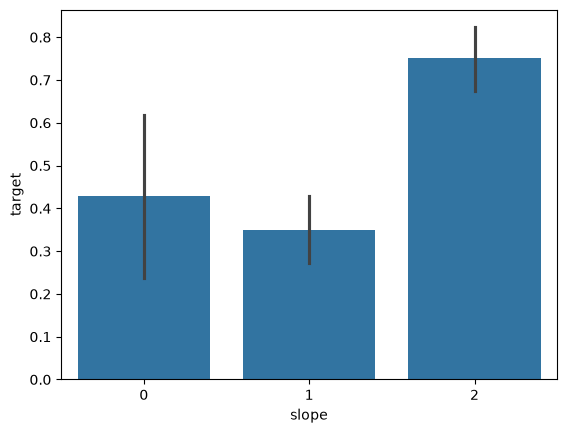

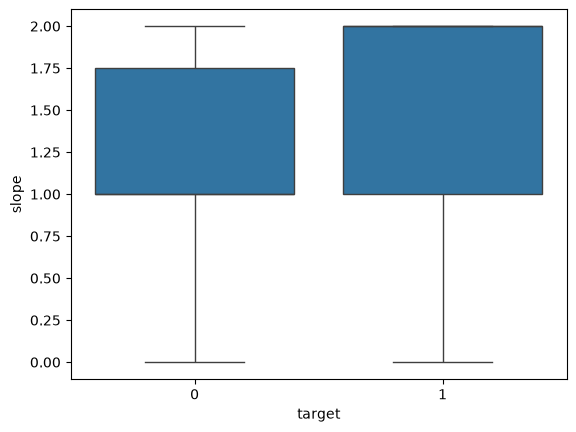

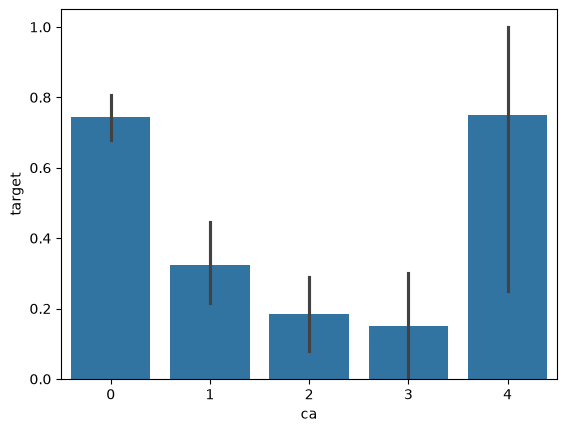

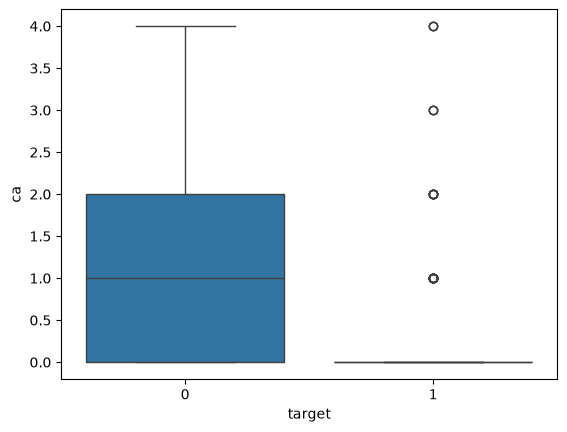

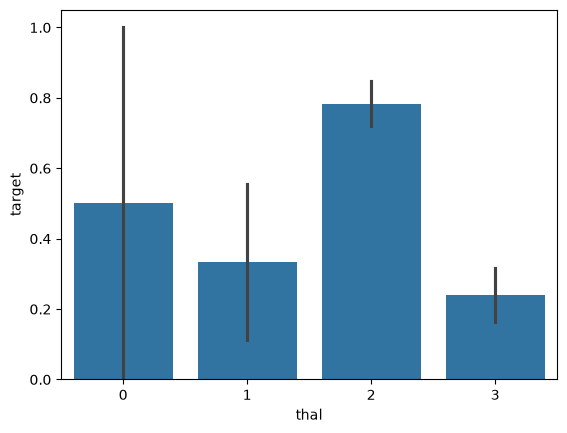

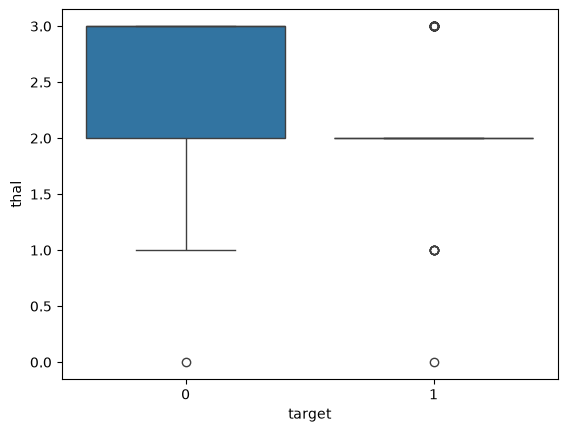

In [90]:
for col in categorical_cols:
    sns.barplot(data=df, x=col, y="target")
    plt.show()
    sns.boxplot(data=df, y=col, x="target")
    plt.show()

In [91]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


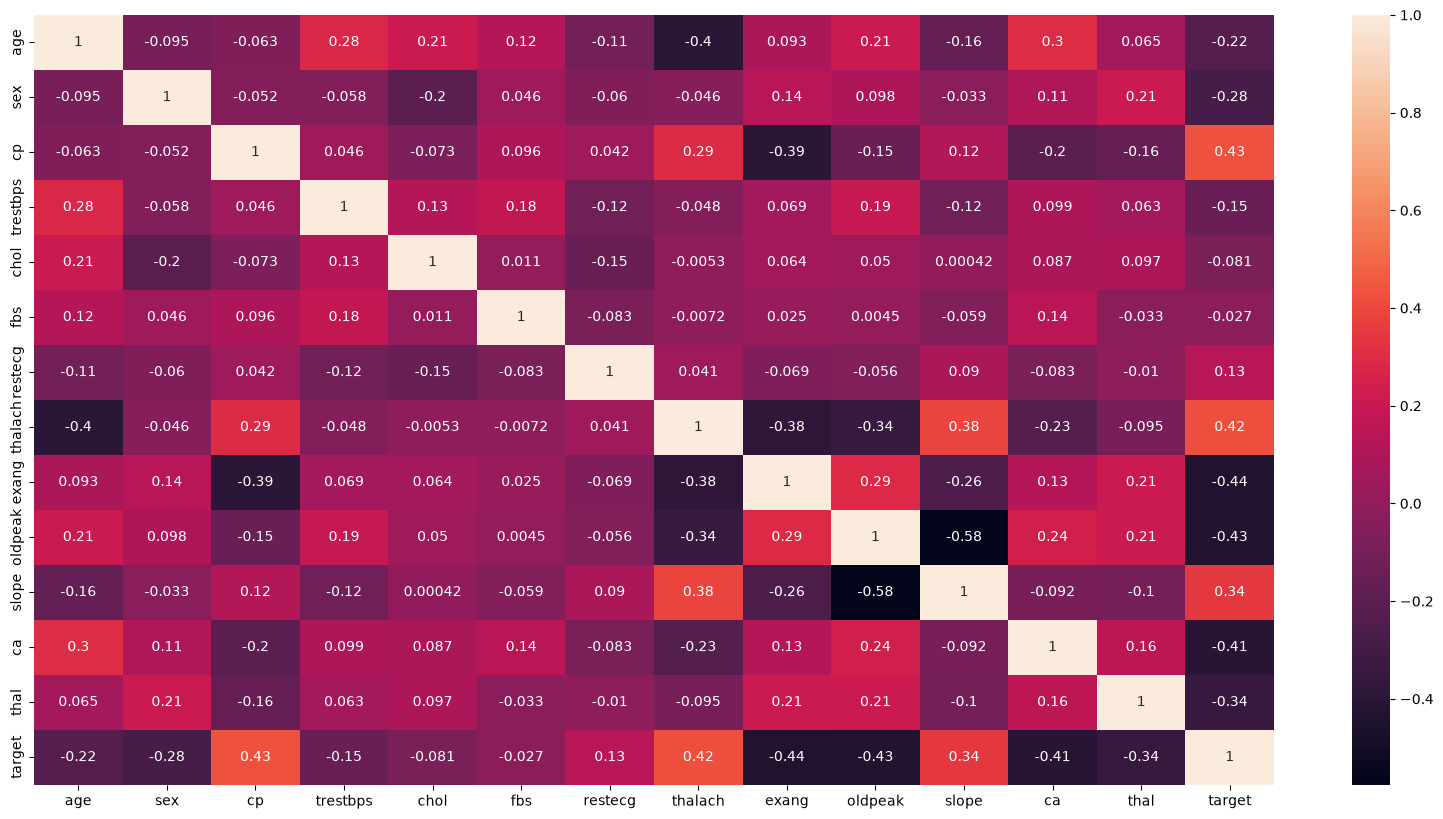

In [92]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [93]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [94]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    [
        (
            "continuous", StandardScaler(), continuous_cols
        ),
         (
            "categorical", OneHotEncoder(handle_unknown="ignore"), one_hot_columns
        )
    ]
)

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
 
models = {
   "Logistic Regression": Pipeline(
       [
            ("preprocessor", preprocessor),
            ("model", LogisticRegression())
      ]
   ),
   "Naive Bayes": Pipeline([
            ("preprocessor", preprocessor),
            ("model", GaussianNB())
      ]),
   "KNN": Pipeline([
            ("preprocessor", preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=5))
      ]),
   "Decision Tree": Pipeline([
            ("preprocessor", preprocessor),
            (
                "model", DecisionTreeClassifier(
                  max_depth=4,
                  min_samples_split=10,
                  min_samples_leaf=5),
            )
            ]), 
   "SVM": Pipeline([
            ("preprocessor", preprocessor),
            ("model", SVC(kernel="linear"))
      ]),
}

In [97]:
results = []
trained_models = {}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

for model_name, model in models.items():
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy",error_score="raise")

    model.fit(X_train, y_train)
    trained_models[model_name] = model
    y_pred = model.predict(X_test)
    
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test,y_pred),
        "precision": precision_score(y_test,y_pred),
        "recall": recall_score(y_test,y_pred),
        "f1": f1_score(y_test,y_pred),
        "cv_score": cv_score.mean()
    })

In [99]:
result_df = pd.DataFrame(results)
result_df.round(3)

,model,accuracy,precision,recall,f1,cv_score
0,Logistic Regression,0.770,0.742,0.793,0.767,0.830
1,Naive Bayes,0.705,0.690,0.690,0.690,0.788
2,KNN,0.738,0.697,0.793,0.742,0.797
3,Decision Tree,0.738,0.667,0.897,0.765,0.742
4,SVM,0.754,0.706,0.828,0.762,0.834


In [100]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(trained_models["SVM"], "../models/heart_model.pkl")

['../models/heart_model.pkl']